Вам предстоит решить задачу классификации сложных цветных изображений — датасет **CIFAR-10**.
В нем 10 классов: самолеты, автомобили, птицы, кошки, олени, собаки, лягушки, лошади, корабли, грузовики.

**Ваша цель:** Пробить "потолок" точности (`accuracy`) в **50%** на тестовой выборке.
**Главное правило:** Запрещено использовать любые слои, кроме `Dense`, `Dropout`, `Input` и слоев регуляризации. Никаких сверточных нейросетей (CNN)! Только полносвязные сети.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras import regularizers

# Вспомогательная функция для отрисовки графиков
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()

    plt.show()

### Шаг 1: Загрузка и подготовка данных
Изображения цветные, размер 32x32 пикселя, 3 канала (RGB).
1. Загрузите датасет CIFAR-10.
2. "Распрямите" изображения (Flatten) в плоский вектор. Какова будет его размерность?
3. Масштабируйте данные (от 0 до 1).
4. Закодируйте метки классов (y) методом One-Hot Encoding.

In [3]:
# Загрузка данных
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Распрямление изображения
x_train = X_train.reshape(X_train.shape[0], -1)
x_test  = X_test.reshape(X_test.shape[0], -1)
print("Flatten dim =", x_train.shape[1])

# Масштабирование
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# One-Hot Encoding
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test  = keras.utils.to_categorical(y_test, num_classes=10)

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Flatten dim = 3072
(50000, 3072) (50000, 10) (10000, 3072) (10000, 10)


### Шаг 2: Модель "Слабое звено" (Недообучение)
Давайте посмотрим, что будет, если дать сложной задаче слишком простую модель.
1. Создайте сеть всего с одним скрытым слоем на **32 нейрона** (активация `relu`).
2. Добавьте выходной слой. *Внимание! Подумайте, какая функция активации и loss-функция нужны для 10 классов.*
3. Обучите на 15 эпохах.
4. Постройте графики. Сделайте выводы: хватает ли емкости этой сети, чтобы уловить закономерности в цветных фото?

Model: "weak_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        98,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,666 (385.41 KB)

 Trainable params: 98,666 (385.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1507 - loss: 2.2284 - val_accuracy: 0.1640 - val_loss: 2.1551
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1724 - loss: 2.1259 - val_accuracy: 0.1918 - val_loss: 2.1341
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1966 - loss: 2.0767 - val_accuracy: 0.2026 - val_loss: 2.0560
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2058 - loss: 2.0413 - val_accuracy: 0.2100 - val_loss: 2.0231
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2274 - loss: 2.0081 - val_accuracy: 0.2412 - val_loss: 1.9971
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2440 - loss: 1.9819 - val_accuracy: 0.2460 - val_loss: 1.9784
Epoch 7/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2497 - loss: 1.9663 - val_accuracy: 0.2434 - val_loss: 1.9605
Epoch 8/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2527 - loss: 1.9540 - val_accuracy: 

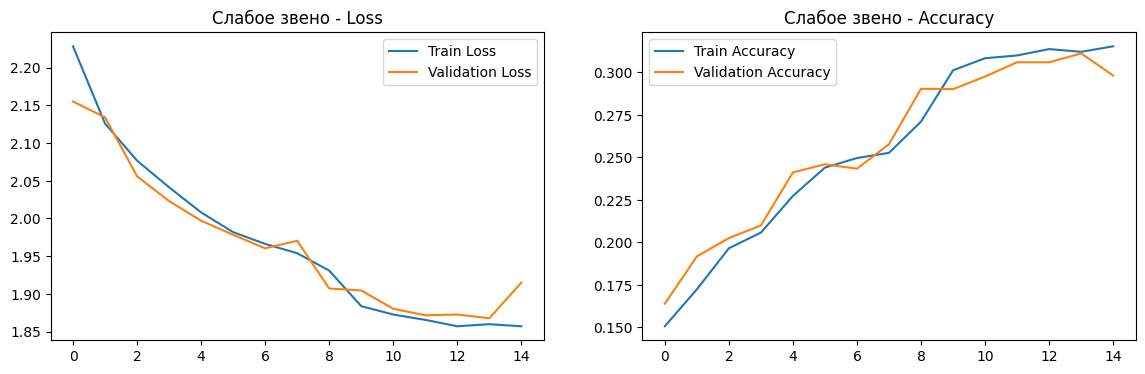


Точность на тестовой выборке: 0.3001 (30.01%)


In [ ]:
model_weak = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')], name="weak_model")

model_weak.summary()

model_weak.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

history_weak = model_weak.fit(
    x_train, y_train,
    epochs=15,
    batch_size=256,
    validation_split=0.1,
    verbose=1)

plot_history(history_weak, "Слабое звено")

# Оценка на тесте
test_loss, test_acc = model_weak.evaluate(x_test, y_test, verbose=0)
print(f"\nТочность на тестовой выборке: {test_acc:.4f} ({test_acc*100:.2f}%)")

**Вывод:** Полученные результаты демонстрируют, что точность на обучающей выборке постепенно увеличивается с 15% до 31%. Точность на тестовой выборке имеет соспоставимые значения и составляет ~30%. Разница между train и validation небольшая, что говорит о том, что модель не переобучается. Тем не менее, значения точности остаются достаточно низкими, емкости данной сети недостаточно для решения задачи классификации цветных изображений.

### Шаг 3: Модель "Зубрила" (Переобучение)
Простая модель не справилась (метрики застряли на ~30%). Дадим сети больше мощности!
1. Постройте глубокую полносвязную сеть (например, скрытые слои на **1024, 512 и 256 нейронов**).
2. **Не используйте** Dropout или регуляризацию.
3. Обучите на 25 эпохах.
4. Постройте графики. **Вопрос для размышления:** На какой эпохе сеть перестала учиться обобщать и начала просто "зазубривать" тренировочные данные? Как вы это поняли по графику Loss?

Model: "overfit_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.2961 - loss: 1.9726 - val_accuracy: 0.3402 - val_loss: 1.8059
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - accuracy: 0.3861 - loss: 1.7112 - val_accuracy: 0.3918 - val_loss: 1.7072
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 127ms/step - accuracy: 0.4203 - loss: 1.6255 - val_accuracy: 0.4380 - val_loss: 1.5863
Epoch 4/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.4499 - loss: 1.5458 - val_accuracy: 0.4434 - val_loss: 1.5596
Epoch 5/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - accuracy: 0.4605 - loss: 1.5152 - val_accuracy: 0.4738 - val_loss: 1.4900
Epoch 6/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.4756 - loss: 1.4665 - val_accuracy: 0.4690 - val_loss: 1.4924
Epoch 7/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.4890 - loss: 1.4346 - val_accuracy: 0.4714 - val_loss: 1.4797
Epoch 8/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 122ms/step - accuracy: 0.4979 - loss: 1

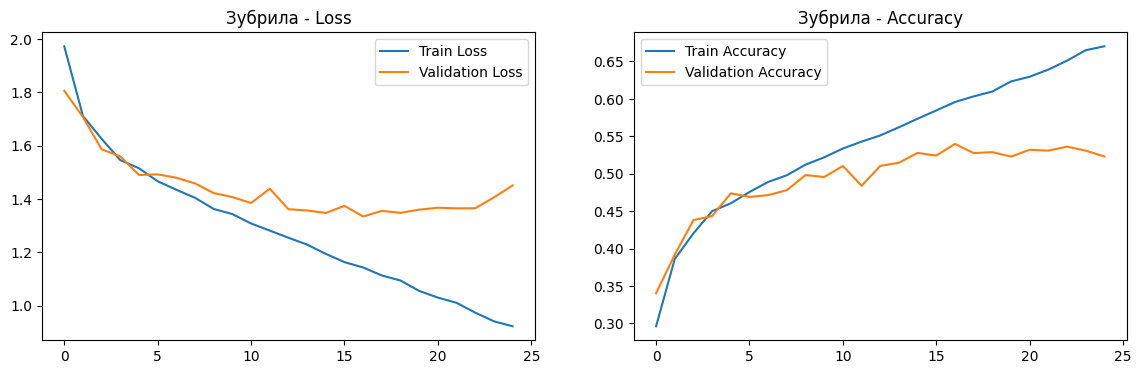


Точность на тестовой выборке: 0.5208 (52.08%)


In [ ]:
model_overfit = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')], name="overfit_model")

model_overfit.summary()

model_overfit.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

history_overfit = model_overfit.fit(
    x_train, y_train,
    epochs=25,
    batch_size=256,
    validation_split=0.1,
    verbose=1)

plot_history(history_overfit, "Зубрила")

# Оценка на тесте
test_loss, test_acc = model_overfit.evaluate(x_test, y_test, verbose=0)
print(f"\nТочность на тестовой выборке: {test_acc:.4f} ({test_acc*100:.2f}%)")

**Вывод:** Анализируя полученные графики, можно отметить, что точность на обучающей и валидационной выборках растет, то есть модель начинает успешно обучаться. Однако, примерно после 12 эпохи замтено, что функция потерь на обучающей выборке продолжает стабильно уменьшаться, а на валидационной, наоборот, расти, что указывает на начало переобучения. На графике точности, аналогично, заметно, что после 12 эпохи точность на валидационной выборке перестаёт расти и начинает снижаться, тогда как точность на обучающей выборке продолжает увеличиваться.

### Шаг 4: Вызываем подкрепление (Callbacks & Regularization)

Теперь применим весь арсенал. Создайте новую архитектуру, взяв за основу сеть из Шага 3, но добавив инструменты удержания:
1. **Dropout**: Добавьте слои `Dropout` (например, 0.3 или 0.4) после крупных `Dense` слоев.
2. **L2 Регуляризация**: (Опционально) добавьте `kernel_regularizer='l2'` в один из слоев.
3. **Callbacks**: При вызове метода `.fit()` передайте список из трех коллбэков:
   - `EarlyStopping`: остановка, если `val_accuracy` не растет 8 эпох (`restore_best_weights=False`, т.к. будем сохранять чекпоинтом).
   - `ReduceLROnPlateau`: уменьшение learning rate (factor=0.5), если метрика застряла на плато на 3 эпохи.
   - `ModelCheckpoint`: сохраняйте **только лучшие** веса в файл `best_cifar10_model.keras`.
4. Запустите обучение на 70 эпох. Коллбэки сами остановят процесс в нужный момент.

Epoch 1/70
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.1754 - loss: 2.4125
Epoch 1: val_accuracy improved from None to 0.33340, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.2325 - loss: 2.2054 - val_accuracy: 0.3334 - val_loss: 1.9579 - learning_rate: 0.0010
Epoch 2/70
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3165 - loss: 1.9781
Epoch 2: val_accuracy improved from 0.33340 to 0.36820, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.3242 - loss: 1.9552 - val_accuracy: 0.3682 - val_loss: 1.8515 - learning_rate: 0.0010
Epoch 3/70
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.3436 - loss: 1.8926
Epoch 3: val_accuracy improved from 0.36820 to 0.40480, saving model to best_cifar10_model.keras

Epoch 3: finished saving model to best_

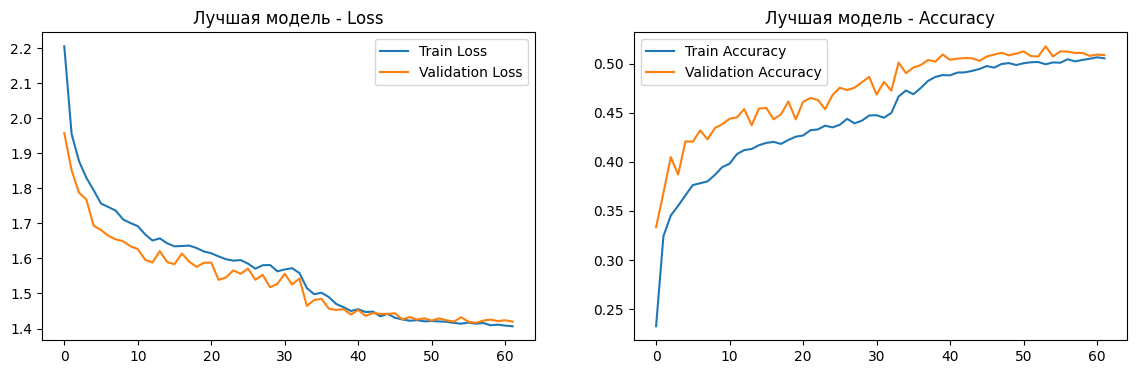


Точность на тестовой выборке: 0.5059 (50.59%)


In [9]:
model_reg = keras.Sequential([
    layers.Input(shape=(3072,)),

    layers.Dense(1024, activation='relu',kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')], name="regularized_model")


model_reg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=False,
    verbose=1)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1)

cb_checkpoint = callbacks.ModelCheckpoint(
    "best_cifar10_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1)

history_reg = model_reg.fit(
    x_train, y_train,
    epochs=70,
    batch_size=256,
    validation_split=0.1,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1)

plot_history(history_reg, "Лучшая модель")

model_reg.load_weights('best_cifar10_model.keras')
test_loss, test_acc = model_reg.evaluate(x_test, y_test, verbose=0)
print(f"\nТочность на тестовой выборке: {test_acc:.4f} ({test_acc*100:.2f}%)")

### Шаг 5: Оценка результата
1. Загрузите лучшие веса из сохраненного файла (`keras.models.load_model`).
2. Сделайте `.predict()` на тестовой выборке (`X_test`).
3. Выведите итоговое значение `accuracy_score`. Смогли ли вы преодолеть барьер в 50%?
4. Напишите краткий вывод: какой инструмент по вашему мнению оказал наибольшее влияние на результат?

In [10]:
# Загрузка лучшей модели
model_loaded = keras.models.load_model('best_cifar10_model.keras')
print("Модель загружена успешно!")

# Предсказания на тестовой выборке
y_pred_proba = model_loaded.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# Итоговая accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\nИтоговая точность на тестовой выборке: {acc:.4f} ({acc*100:.2f}%)")

Модель загружена успешно!

Итоговая точность на тестовой выборке: 0.5059 (50.59%)


**Вывод:** Итоговое значение accuracy_score на тестовой выборке составил 50.59%, что говорит о преодолении барьера 50%.

Исходя из полученных результатов, можно отметить, что в процессе обучения наблюдается стабильный рост точности на обучающей и валидационной выборках. При этом разница между выборками остается небольшой, что говорит об отсутствии выраженного переобучения, это связано с применением методов регуляризации (Dropout и L2 регуляризация).

На начальных эпохах можно заметить, что модель обучается достаточно быстро, с 20-30 эпох рост точности замедляется, а после 40 эпохи выходит практически на плато, обучение останавливается на 62 эпохе с помощью EarlyStopping.

Наибольшее влияние на улучшение качества модели оказал ReduceLROnPlateau, что заметно из полученных результатов. Снижение скорости обучения на более поздних этапах позволило более точно настроить веса модели, что привело к дополнительному росту точности.